# ESP memory system under DMA load: the 4x4 campaign

**13 accelerators, one memory tile, on a Xilinx VCU118 (xcvu9p).**

A second campaign, run after the 3x3 study and reported separately. Same three arms --
baseline, multiOT depth 2, multiOT depth 4 -- on a larger mesh, with two instrumentation
defects corrected and a sweep extended where the 3x3 could not see.

It exists to answer three things the 3x3 left open:

1. **Does the one-beat-per-accelerator-cycle limit survive at higher fan-in?** The 3x3
   stopped at 6 accelerators, where all three arms had already converged.
2. **Does the inbound request plane ever stall?** The 3x3's counter for this was wired to an
   unused queue and read zero regardless, so the question was unmeasured rather than answered.
3. **Where exactly is the throughput peak?** The 3x3 burst axis jumped 32 -> 128 -> 256,
   which brackets the peak without locating it.

505 runs per arm, 3168 accelerator rows, zero errors, zero timeouts, zero malformed rows in
all three captures.

## What this campaign establishes

**The rate quantum holds exactly, out to 13 accelerators.** Measured 0.9998-1.0016 64-bit
words per accelerator clock cycle in every arm at every concurrency level. Aggregate
throughput is flat in the number of accelerators.

**The inbound request plane does stall, heavily, and only above 6 accelerators.** In
read-only traffic it is 0.0% at 1, 2, 4 and 6 accelerators and reaches 93-98% at 10 and 13.
The 3x3 stopped one step below where the effect begins.

**Neither backpressure counter explains the throughput.** Inbound stall sits at 93-96% while
throughput varies 3.4x across the same bursts, and its correlation with throughput is weakly
*positive*.

**multiOT's benefit keeps growing past 6 accelerators.** Read-only at burst 8: 2.20x at 6
accelerators, **3.10x at 10**. The 3x3 measured the effect just below its maximum.

**The peak is located.** Baseline peaks at burst 64; both multiOT arms peak at burst 32.

**multiOT costs up to 6% in a narrow band** -- balanced traffic, 2 accelerators, bursts 16-64
-- reproducibly.

Sections 6, 7 and 8 separate what is established from what is not, and from what stays open.
Every number is computed from the raw CSVs by `charlib.py`.


In [1]:
# Colab bootstrap. A no-op anywhere else.
import os, sys, subprocess

REPO = "https://github.com/eugeniomuscinelli/esp-mem-characterization.git"

if "google.colab" in sys.modules and not os.path.isfile("charlib.py"):
    name = REPO.rsplit("/", 1)[-1].removesuffix(".git")
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", "-q", REPO], check=True)
    os.chdir(name)

print("working directory:", os.getcwd())


working directory: /home/eugenio/char_results


In [2]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
import charlib as cl

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120,
                     "font.size": 10, "figure.facecolor": "white"})

arms = cl.load_all("4x4")
g = cl.occupancy_all(arms)

for k, a in arms.items():
    print(f"{a.label:<30s} {len(a.runs):>5d} accelerator rows, {len(a.mem):>4d} memory rows, "
          f"{len(a.tile):>5d} tile rows")
print("\ndenominator used for occupancies:",
      cl.occupancy(arms["baseline_ot1_gate0"]).mem_cyc_source.unique()[0])


baseline (no multiOT)           3168 accelerator rows,  505 memory rows,  8080 tile rows
multiOT depth 4, barrier on     3168 accelerator rows,  505 memory rows,  8080 tile rows
multiOT depth 2, barrier on     3168 accelerator rows,  505 memory rows,  8080 tile rows

denominator used for occupancies: measured


---
# 1. What differs from the 3x3 campaign

Same board, same accelerator, same three arms, same measurement method. Four things changed.

## 1.1 The SoC

| | 3x3 | 4x4 |
|---|---|---|
| mesh | 3x3, 9 tiles | 4x4, 16 tiles |
| accelerators | 6 | **13** |
| memory tiles | 1, at (0,0) | 1, at (0,0) |
| hop distance to memory | 2 to 3 | **1 to 5** |

One memory tile in both, so the question remains where a single memory path saturates.

## 1.2 Two instrumentation defects corrected

**`noc_stop_req` now measures inbound refusal.** In the 3x3 it tapped `test6_stop_in`, which
is the router refusing a flit the tile *injects* on plane 6 -- and that half-plane carries
coherent DMA responses, which this workload never generates. It therefore read zero in every
3x3 run regardless of what the inbound path was doing. It now taps `noc6_out_stop`, which is
`dma_rcv_full` qualified by a flit actually being offered.

The plane map, read from `mem_tile_q.vhd`, with the direction that matters:

| RTL signal | monitor plane | direction | carries |
|---|---|---|---|
| `noc4_in` | 3 | memory tile -> accelerator | DMA responses: read data |
| `noc6_out` | 5 | accelerator -> memory tile | DMA requests: descriptors + write data |

The suffixes are written from the network's point of view: `nocN_in` is the tile injecting,
`nocN_out` is the network delivering to the tile. The RTL numbers planes 1-6 while the
monitor indexes them 0-5, so RTL `noc4` is monitor plane 3.

**A free-running cycle counter was added** at monitor index 66, in the monitor's own clock
domain and latched by the same burst write as every other counter. Occupancies are now
exact: in the 3x3, `dma_rcv_starved` exceeded 100% in 78 of 576 runs because the denominator
came from the CPU's cycle count, which ticks at half the rate over a slightly different
window. Here no occupancy exceeds its denominator in any of the 1515 rows.

## 1.3 The sweep

| axis | 3x3 | 4x4 |
|---|---|---|
| concurrent accelerators | 1, 2, 4, 6 | **1, 2, 4, 6, 8, 10, 13** |
| descriptor granularity | 8, 32, 128, 256, 1024, 4096, 16384 | **8, 16, 32, 64, 128, 256, 512, 1024, 4096, 16384** |
| mixed read:write ratios | at burst 256 only | **at burst 32 and 256** |
| runs per arm | 193 | **505** |

Each accelerator moves the same total bytes at every burst size (65536 64-bit beats = 512
KB), so the burst axis varies descriptor count and nothing else.


---
# 2. Validation

Five checks, all three arms.


In [3]:
for k, a in arms.items():
    it = cl.integrity(a)
    bad = sum(a.dropped.values())
    ok = it["data_errors"] == 0 and it["timeouts"] == 0 and bad == 0
    print(f"{a.label:<30s} rows {it['acc_rows']:>5d}  configs {it['configs']:>3d}  "
          f"errors {it['data_errors']}  timeouts {it['timeouts']}  "
          f"malformed {bad}   {'PASS' if ok else 'CHECK'}")


baseline (no multiOT)          rows  3168  configs  24  errors 0  timeouts 0  malformed 0   PASS
multiOT depth 4, barrier on    rows  3168  configs  24  errors 0  timeouts 0  malformed 0   PASS
multiOT depth 2, barrier on    rows  3168  configs  24  errors 0  timeouts 0  malformed 0   PASS


**(a) Correctness and capture integrity.** Zero data errors, zero timeouts, zero malformed
rows in all three captures. Each 1:1 configuration verifies its copy, so a crossed register
or mis-sized descriptor would appear as a non-zero error count.

**(b) The register cross-check**, against the memory tile's own write counter rather than
against software: read-only must write nothing, 4:1 a quarter of what it reads, 1:4 four
times as much.


In [4]:
w = cl.write_ratio_check(arms["baseline_ot1_gate0"])
w["ratio"] = w["rd_per_group"].astype(str) + ":" + w["wr_per_group"].astype(str)
w[["ratio", "runs", "write_beats/expected", "read_beats/expected", "mean_write_beats"]]


,ratio,runs,write_beats/expected,read_beats/expected,mean_write_beats
0,1:0,210.0,NaN,1.007061,4.932048e+02
1,1:1,210.0,1.002355,1.011140,4.124337e+05
2,1:4,42.0,1.000589,1.026774,1.648256e+06
3,4:1,42.0,1.009418,1.007927,1.034782e+05


**(c) Occupancies are now bounded by their own denominator** -- the defect the free-running
counter was added to fix.


In [5]:
rows = []
for k, a in arms.items():
    o = cl.occupancy(a)
    r = {"arm": a.label}
    for c in ("dma_rcv_starved", "dma_snd_blocked", "noc_stop_rsp", "noc_stop_req",
              "ddr_read_busy"):
        pct = 100 * o[c] / o.mem_cyc
        r[c + " max %"] = round(pct.max(), 2)
        r[c + " >100%"] = int((pct > 100.0001).sum())
    rows.append(r)
pd.DataFrame(rows).set_index("arm").T


arm,baseline (no multiOT),"multiOT depth 4, barrier on","multiOT depth 2, barrier on"
dma_rcv_starved max %,99.99,99.99,99.99
dma_rcv_starved >100%,0.00,0.00,0.00
dma_snd_blocked max %,44.69,49.49,49.49
dma_snd_blocked >100%,0.00,0.00,0.00
noc_stop_rsp max %,49.41,49.59,49.59
noc_stop_rsp >100%,0.00,0.00,0.00
noc_stop_req max %,98.32,96.99,97.86
noc_stop_req >100%,0.00,0.00,0.00
ddr_read_busy max %,97.65,99.37,99.37
ddr_read_busy >100%,0.00,0.00,0.00


No occupancy exceeds 100% anywhere. In the 3x3, `dma_rcv_starved` reached 141.5% in 78 of
576 runs.

**(d) Repeatability**, per configuration rather than as one headline number.


In [6]:
rows = []
for k, a in arms.items():
    c = pd.concat([cl.completion(a, r, w_).assign(ratio=f"{r}:{w_}")
                   for r, w_ in a.runs.groupby(["rd_per_group",
                                                "wr_per_group"]).groups.keys()])
    rows.append(pd.Series({"arm": a.label,
                           "median spread %": c["spread_pct"].median(),
                           "90th pct %": c["spread_pct"].quantile(0.9),
                           "worst %": c["spread_pct"].max(),
                           "configs > 1%": int((c["spread_pct"] > 1).sum()),
                           "configs total": len(c)}))
pd.DataFrame(rows).round(3)


,arm,median spread %,90th pct %,worst %,configs > 1%,configs total
0,baseline (no multiOT),0.019,0.104,6.188,3,168
1,"multiOT depth 4, barrier on",0.047,1.006,6.156,17,168
2,"multiOT depth 2, barrier on",0.035,0.516,5.215,6,168


**(e) Concurrency.** The CPU starts accelerators in a loop; what matters is that the skew is
negligible against the run length.


In [7]:
r = arms["baseline_ot1_gate0"].runs
sk = r.groupby("n_active").agg(max_start_skew_cycles=("start_skew", "max"),
                               median_run_cycles=("cyc_all_done", "median"))
sk["skew as % of run"] = (100 * sk.max_start_skew_cycles / sk.median_run_cycles).round(4)
sk


,max_start_skew_cycles,median_run_cycles,skew as % of run
n_active,,,
1,131,144033.0,0.0910
2,16583,252832.5,6.5589
4,49420,472678.5,10.4553
6,82227,717743.0,11.4563
8,114989,952630.5,12.0707
10,147769,1185438.0,12.4654
13,196924,1537118.0,12.8112


---
# 3. The rate quantum at 13 accelerators

The 3x3 found that aggregate throughput at long descriptors is one 64-bit beat per
accelerator clock cycle, independent of how many accelerators run. The 4x4 tests that over
twice the fan-in.


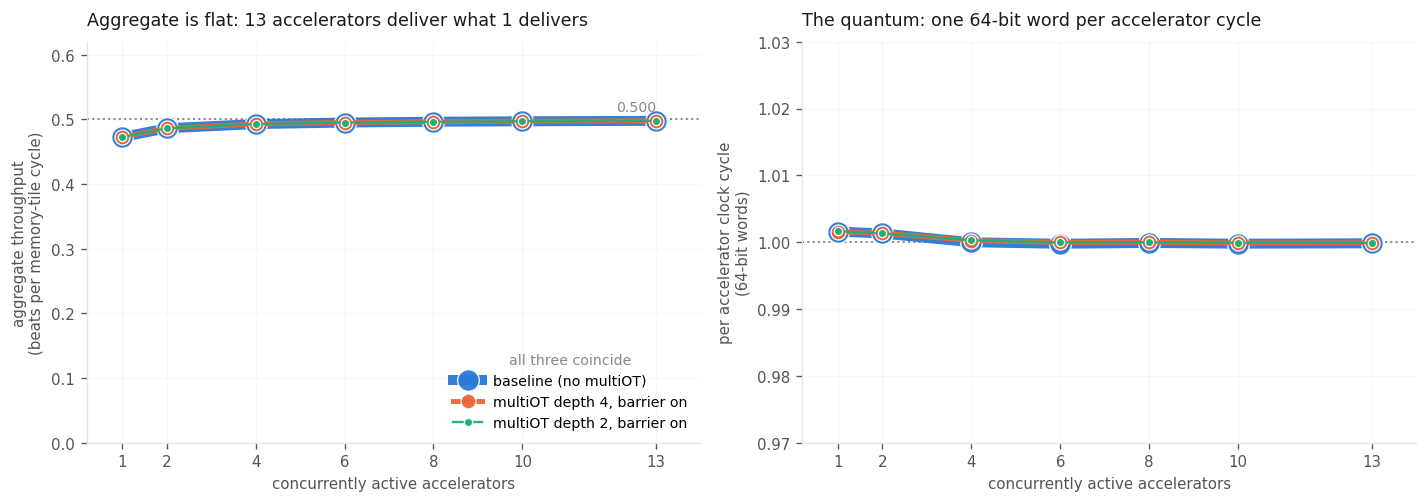

In [8]:
fig = cl.plot_quantum(arms)
plt.show()


In [9]:
cl.per_accelerator_share(arms, burst=16384, rdg=1, wrg=0)


,label,n_active,tot_beats_per_cyc,per_acc,words_per_acc_cyc,noc_stop_rsp_pct
0,baseline (no multiOT),1,0.472515,0.472515,1.001588,46.681293
1,baseline (no multiOT),2,0.486064,0.243032,1.001301,48.138483
2,baseline (no multiOT),4,0.492600,0.123150,0.999984,48.867294
3,baseline (no multiOT),6,0.494924,0.082487,0.999764,49.109440
4,baseline (no multiOT),8,0.496215,0.062027,0.999885,49.262387
5,baseline (no multiOT),10,0.496901,0.049690,0.999771,49.328316
6,baseline (no multiOT),13,0.497616,0.038278,0.999832,49.402834
7,"multiOT depth 2, barrier on",1,0.472536,0.472536,1.001649,46.798421
8,"multiOT depth 2, barrier on",2,0.486068,0.243034,1.001312,48.300535
9,"multiOT depth 2, barrier on",4,0.492746,0.123186,1.000291,49.065634


`words_per_acc_cyc` is the aggregate expressed in the accelerator's own clock, so 1.0 means
one 64-bit word per accelerator cycle. It is **0.9998 to 1.0016 in all 21 rows** -- three
arms by seven concurrency levels -- with no fitted parameter. 64 bit x 78.125 MHz = 625 MB/s.

Aggregate throughput rises only from 0.4725 to 0.4976 beats per memory-tile cycle as the
number of accelerators goes from 1 to 13, while the per-accelerator share falls as 1/n.
Thirteen accelerators deliver what one delivers.

The residual rise with n is a measurement-window effect, not a throughput effect: the
monitored window includes a fixed overhead of monitor reads, which is a larger fraction of a
shorter run. `words_per_acc_cyc`, which uses the accelerator's own elapsed count, is flat at
1.000 and is the cleaner figure.


---
# 4. Inbound backpressure, measured for the first time

`noc_stop_req` counts cycles the memory tile refused an inbound DMA request flit. In the 3x3
this counter was inert. Here it is live.


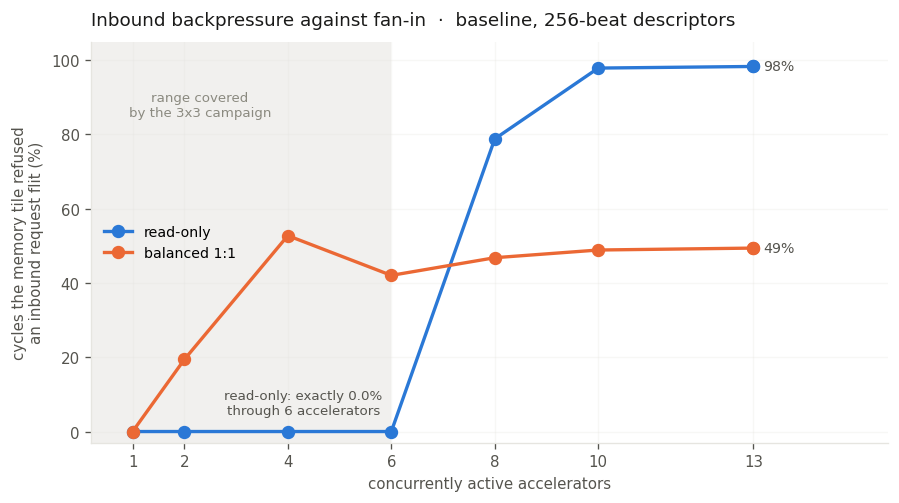

In [10]:
fig = cl.plot_inbound_onset(arms)
plt.show()


In [11]:
b = g[(g.arm == "baseline_ot1_gate0") & (g.rd == 1) & (g.wr == 0)]
print("baseline, READ-ONLY, inbound stall as % of memory-tile cycles")
display(b.pivot_table(index="burst", columns="n_active",
                      values="noc_stop_req_pct").round(1))
b2 = g[(g.arm == "baseline_ot1_gate0") & (g.rd == 1) & (g.wr == 1)]
print("baseline, BALANCED 1:1")
display(b2.pivot_table(index="burst", columns="n_active",
                       values="noc_stop_req_pct").round(1))


baseline, READ-ONLY, inbound stall as % of memory-tile cycles


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,0.0,0.0,0.0,0.0,9.9,93.5,93.5
16,0.0,0.0,0.0,0.0,10.4,94.3,94.4
32,0.0,0.0,0.0,0.0,9.4,95.2,95.4
64,0.0,0.0,0.0,0.0,4.8,96.2,96.4
128,0.0,0.0,0.0,0.0,54.6,97.6,97.9
256,0.0,0.0,0.0,0.0,78.8,97.9,98.3
512,0.0,0.0,0.0,0.0,86.7,97.5,98.2
1024,0.0,0.0,0.0,0.0,88.6,96.1,97.3
4096,0.0,0.0,0.0,0.0,74.2,87.4,91.8


baseline, BALANCED 1:1


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,0.0,0.0,77.5,77.3,74.0,74.6,79.6
16,0.0,14.0,73.1,71.0,71.4,71.6,73.8
32,0.0,16.6,61.2,63.4,63.7,65.2,67.1
64,0.0,10.0,27.7,42.9,47.2,49.5,52.1
128,0.0,11.8,53.4,39.8,45.7,48.3,48.9
256,0.0,19.4,52.8,42.1,46.8,48.9,49.4
512,0.0,22.0,51.0,41.7,45.9,47.7,48.3
1024,0.0,22.9,49.8,41.4,45.4,47.1,47.7
4096,0.0,22.8,47.4,41.0,45.2,46.9,46.9


Two facts, both measured:

**The request plane does stall, and heavily.** In read-only traffic at 10 and 13
accelerators it is refused for **93 to 98%** of memory-tile cycles across most of the burst
range. The 3x3 could not have seen this: it reports **exactly 0.0%** at 1, 2, 4 and 6
accelerators, and the 3x3 swept no further.

**The onset is sharp and sits just above the 3x3's limit.** Read-only goes 0.0% at 6
accelerators, 3-89% at 8, and 93-98% at 10. In balanced traffic the onset is earlier, around
4 accelerators, because the inbound path then carries write data as well as descriptors.

## 4.1 It is not what limits throughput

The same caution applies as to the response plane in the 3x3.


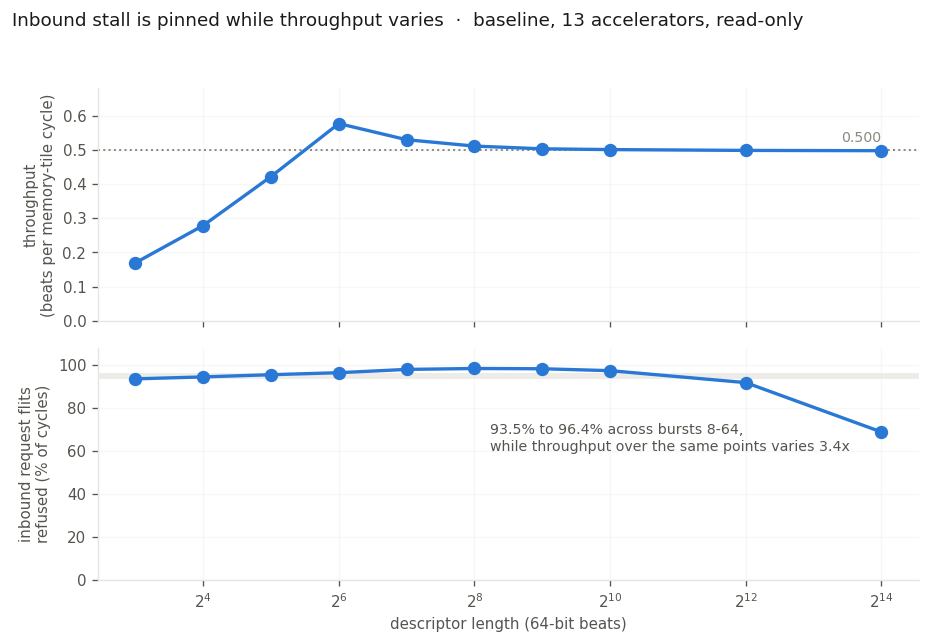

In [12]:
fig = cl.plot_inbound_not_the_limit(arms)
plt.show()


In [13]:
s = g[(g.arm == "baseline_ot1_gate0") & (g.rd == 1) & (g.wr == 0) & (g.n_active == 13)]
display(s[["burst", "tot_beats_per_cyc", "noc_stop_req_pct", "noc_stop_rsp_pct",
           "ddr_read_busy_pct"]].sort_values("burst").round(2).reset_index(drop=True))

bb = g[g.arm == "baseline_ot1_gate0"]
print(f"over all 160 baseline operating points:")
print(f"  corr(throughput, inbound stall)  = {bb.tot_beats_per_cyc.corr(bb.noc_stop_req_pct):+.3f}")
print(f"  corr(throughput, outbound stall) = {bb.tot_beats_per_cyc.corr(bb.noc_stop_rsp_pct):+.3f}")


,burst,tot_beats_per_cyc,noc_stop_req_pct,noc_stop_rsp_pct,ddr_read_busy_pct
0,8,0.17,93.51,0.00,80.37
1,16,0.28,94.40,0.00,83.09
2,32,0.42,95.43,0.26,86.45
3,64,0.58,96.37,25.55,89.06
4,128,0.53,97.90,36.63,92.33
5,256,0.51,98.32,41.63,95.44
6,512,0.50,98.20,45.65,96.63
7,1024,0.50,97.32,47.58,97.10
8,4096,0.50,91.76,49.06,97.58
9,16384,0.50,68.80,49.40,97.65


over all 160 baseline operating points:
  corr(throughput, inbound stall)  = +0.161
  corr(throughput, outbound stall) = +0.469


At 13 accelerators, read-only, inbound stall moves only from 93.5% to 96.4% across bursts 8
to 64 while throughput over the same points moves from 0.17 to 0.58 -- a factor of 3.4. A
quantity that is pinned near its maximum while the thing it supposedly limits varies
threefold is not the limit.

Both correlations with throughput are **positive**, so on this data more backpressure
accompanies more throughput, not less.

What the counter does establish is that at high fan-in the accelerators offer work far faster
than the memory tile accepts it: the request queue is full almost continuously. That is a
statement about oversubscription of the tile, not about network capacity.


---
# 5. Results

## 5.1 The burst curve, with the peak located

The 3x3 burst axis stepped 32 -> 128 -> 256, which brackets the peak without finding it.
This campaign adds 16, 64 and 512.


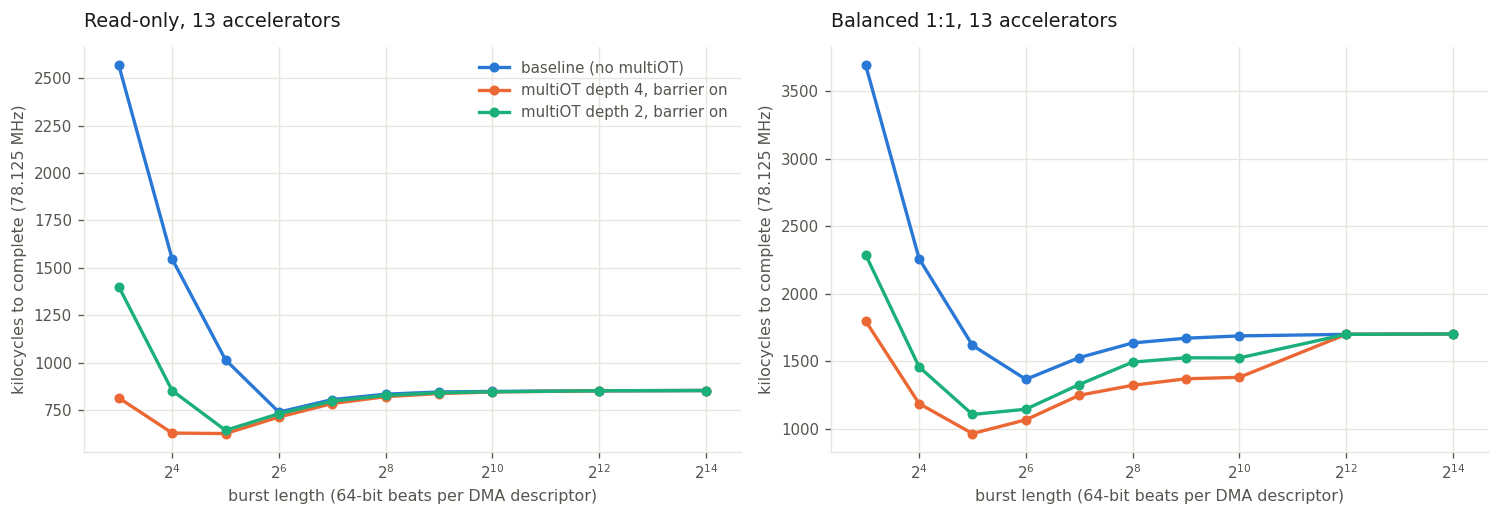

balanced 1:1, 13 accelerators -- peak marked by the maximum of each column
  baseline (no multiOT)          peaks at burst    64  (0.6246)
  multiOT depth 2, barrier on    peaks at burst    32  (0.7703)
  multiOT depth 4, barrier on    peaks at burst    32  (0.8819)


,baseline (no multiOT),"multiOT depth 2, barrier on","multiOT depth 4, barrier on"
burst,,,
8,0.2341,0.3752,0.4763
16,0.3799,0.5859,0.7184
32,0.5286,0.7703,0.8819
64,0.6246,0.7439,0.7979
128,0.5587,0.6414,0.6818
256,0.5214,0.5701,0.6438
512,0.5095,0.5575,0.6205
1024,0.5039,0.5575,0.6152
4096,0.5001,0.5001,0.5001


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
cl.plot_burst_sweep(arms, axes[0], n_active=13, rdg=1, wrg=0)
axes[0].set_title("Read-only, 13 accelerators", color=cl.INK["primary"],
                  fontsize=11.5, loc="left", pad=12)
cl.legend(axes[0])
cl.plot_burst_sweep(arms, axes[1], n_active=13, rdg=1, wrg=1)
axes[1].set_title("Balanced 1:1, 13 accelerators", color=cl.INK["primary"],
                  fontsize=11.5, loc="left", pad=12)
plt.tight_layout(); plt.show()

p = g[(g.rd == 1) & (g.wr == 1) & (g.n_active == 13)].pivot_table(
    index="burst", columns="arm", values="tot_beats_per_cyc")
p.columns = [cl.LABEL[c] for c in p.columns]
print("balanced 1:1, 13 accelerators -- peak marked by the maximum of each column")
for c in p.columns:
    print(f"  {c:<30s} peaks at burst {p[c].idxmax():>5d}  ({p[c].max():.4f})")
display(p.round(4))


**The baseline peaks at burst 64; both multiOT arms peak at burst 32.** Above burst 4096 all
three arms sit on the quantum and are identical to four decimal places.

## 5.2 The highest throughput measured


In [15]:
best = g.loc[g.tot_beats_per_cyc.idxmax()]
print(f"{cl.LABEL[best.arm]}, burst {int(best.burst)}, "
      f"{int(best.n_active)} accelerators, rd:wr {int(best.rd)}:{int(best.wr)}")
print(f"  {best.tot_beats_per_cyc:.4f} beats per memory-tile cycle")
print(f"  = {best.tot_beats_per_cyc*8*156.25:.0f} MB/s")
print(f"  = {100*best.tot_beats_per_cyc:.0f}% of the 1.25 GB/s MIG AXI port")
print(f"  inbound stall {best.noc_stop_req_pct:.1f}%, outbound stall {best.noc_stop_rsp_pct:.1f}%")


multiOT depth 4, barrier on, burst 32, 13 accelerators, rd:wr 1:1
  0.8819 beats per memory-tile cycle
  = 1102 MB/s
  = 88% of the 1.25 GB/s MIG AXI port
  inbound stall 37.8%, outbound stall 5.5%


**0.88 beats per cycle, 88% of the MIG AXI port**, on the same hardware that sits at 0.50 at
long descriptors. Whatever pins long descriptors at the quantum is absent here. The 3x3's
best was 0.8545 at 6 accelerators; more accelerators raise it slightly.

## 5.3 multiOT against fan-in

This is what the larger mesh was built to measure.


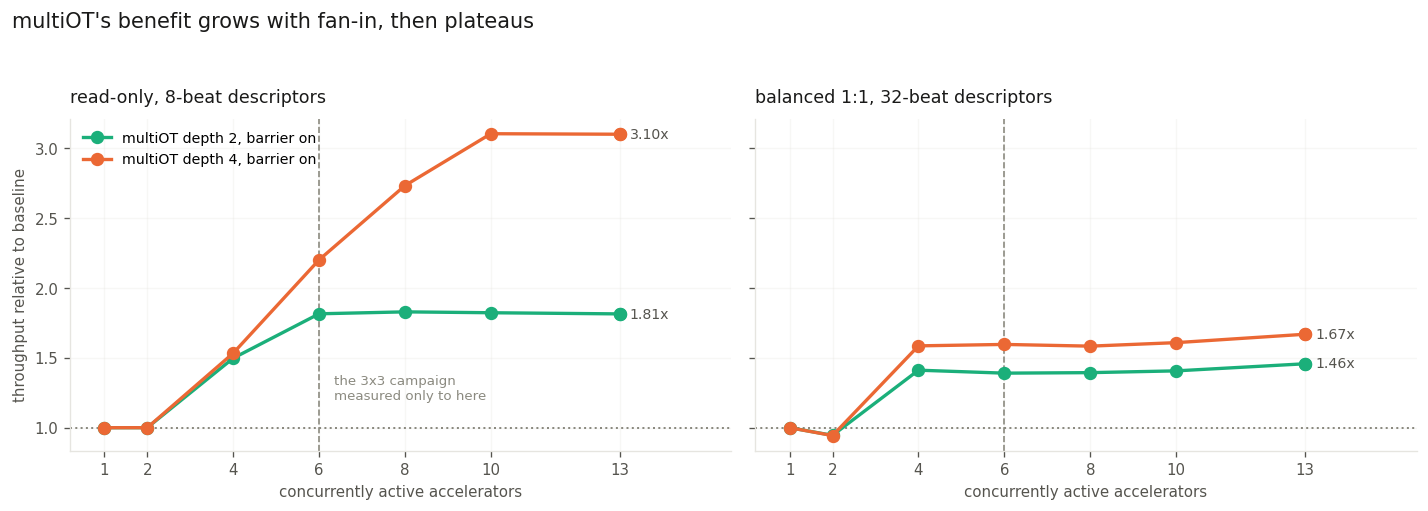

In [16]:
fig = cl.plot_speedup_vs_fanin(arms)
plt.show()


In [17]:
for rd, wr, nm in [(1, 0, "read-only"), (1, 1, "balanced 1:1")]:
    s = g[(g.rd == rd) & (g.wr == wr)].pivot_table(
        index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
    print(f"speedup, multiOT depth 4 over baseline -- {nm}")
    display((s["multiot_ot4_gate1"] / s["baseline_ot1_gate0"]).round(3))


speedup, multiOT depth 4 over baseline -- read-only


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,1.0,1.000,1.533,2.201,2.732,3.103,3.099
16,1.0,1.022,1.667,2.111,2.423,2.428,2.433
32,1.0,1.039,1.405,1.486,1.533,1.550,1.611
64,1.0,1.000,1.015,1.019,1.017,1.015,1.034
128,1.0,1.001,1.017,1.017,1.019,0.997,1.023
256,1.0,1.000,1.014,1.016,1.017,1.014,1.013
512,1.0,0.999,1.007,1.005,1.005,1.005,1.008
1024,1.0,1.000,1.004,1.002,1.003,1.002,1.003
4096,1.0,1.000,1.000,1.000,1.000,1.000,1.000


speedup, multiOT depth 4 over baseline -- balanced 1:1


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,1.0,1.034,1.574,1.951,2.025,2.024,2.034
16,1.0,0.967,1.260,1.892,1.819,1.852,1.891
32,1.0,0.944,1.585,1.596,1.583,1.609,1.669
64,1.0,0.940,1.000,1.088,1.260,1.266,1.277
128,1.0,1.000,0.985,1.351,1.201,1.217,1.220
256,1.0,1.000,1.003,1.325,1.224,1.225,1.235
512,1.0,1.000,1.004,1.228,1.219,1.220,1.218
1024,1.0,1.000,1.127,1.053,1.166,1.198,1.221
4096,1.0,1.000,1.000,1.000,1.000,1.000,1.000


**The benefit keeps growing well past 6 accelerators.** Read-only at burst 8:

| accelerators | 1 | 2 | 4 | 6 | 8 | 10 | 13 |
|---|---|---|---|---|---|---|---|
| speedup | 1.00 | 1.00 | 1.53 | **2.20** | 2.73 | **3.10** | 3.10 |

The 3x3 stopped at 6 accelerators and measured 2.20x. The maximum is **3.10x at 10
accelerators**, after which it plateaus. The 3x3 therefore understated the effect by about a
third.

**Nothing at one accelerator, at any burst or depth** -- 1.000 throughout, as in the 3x3.
`esp_acc_dma` is untouched in every arm and issues one transaction at a time, so a single
accelerator presents the memory tile with one outstanding request however deep the proxy is.

**Nothing at burst 4096 and above**, in any mix at any concurrency -- exactly 1.000.

## 5.4 Where multiOT costs performance


In [18]:
rows = []
for rd, wr, nm in [(1, 0, "1:0"), (1, 1, "1:1")]:
    s = g[(g.rd == rd) & (g.wr == wr)].pivot_table(
        index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
    r = (s["multiot_ot4_gate1"] / s["baseline_ot1_gate0"]).stack()
    for (burst, n), v in r[r < 0.995].items():
        rows.append({"mix": nm, "burst": burst, "n_active": n, "speedup": round(v, 3)})
print("every point where multiOT depth 4 is more than 0.5% SLOWER than baseline:")
display(pd.DataFrame(rows) if rows else "none")

o = {k: cl.occupancy(a) for k, a in arms.items()}
print("\nrepeat spread at the worst point (1:1, burst 64, 2 accelerators):")
for k, oo in o.items():
    s2 = oo[(oo.rd == 1) & (oo.wr == 1) & (oo.burst == 64) & (oo.n_active == 2)]
    v = s2.tot_beats_per_cyc
    print(f"  {arms[k].label:<30s} " + " ".join(f"{x:.4f}" for x in v) +
          f"   spread {100*(v.max()-v.min())/v.mean():.2f}%")


every point where multiOT depth 4 is more than 0.5% SLOWER than baseline:


,mix,burst,n_active,speedup
0,1:1,16,2,0.967
1,1:1,32,2,0.944
2,1:1,64,2,0.940
3,1:1,128,4,0.985



repeat spread at the worst point (1:1, burst 64, 2 accelerators):
  baseline (no multiOT)          0.5688 0.5354 0.5549   spread 6.05%
  multiOT depth 4, barrier on    0.5179 0.5182 0.5231   spread 1.01%
  multiOT depth 2, barrier on    0.5185 0.5211 0.5192   spread 0.51%


There is a **real, reproducible regression**: in balanced traffic at 2 accelerators, bursts
16 to 64, multiOT depth 4 is up to **6.0% slower** than the baseline. The repeat spread at
those points is 0.04%, so this is far outside measurement noise.

It is confined to balanced traffic at low concurrency. Read-only has **no** point below
0.995 anywhere in the sweep. This report does not establish the mechanism.

## 5.5 Outstanding depth: 4 against 2


In [19]:
s = g[(g.rd == 1) & (g.wr == 0)].pivot_table(
    index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
print("depth 4 / depth 2, read-only")
display((s["multiot_ot4_gate1"] / s["multiot_ot2_gate1"]).round(3))


depth 4 / depth 2, read-only


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,1.000,1.000,1.024,1.213,1.494,1.703,1.708
16,1.000,1.000,1.063,1.174,1.354,1.353,1.352
32,1.000,1.000,1.001,1.030,1.029,1.034,1.025
64,1.000,1.001,1.015,1.011,0.988,0.998,1.023
128,1.000,1.000,1.008,1.005,1.007,0.984,1.015
256,1.001,1.000,1.006,1.002,1.001,1.002,1.007
512,1.000,1.000,1.003,1.004,1.001,1.001,1.004
1024,1.000,1.000,1.001,1.000,1.000,1.000,1.001
4096,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In the 3x3 the two depths were within a few percent above burst 32, and depth 4's advantage
at burst 8 was about 1.2x at 6 accelerators. Here that advantage **grows with fan-in**: 1.000
at 1 and 2 accelerators, 1.213 at 6, and **1.708 at 10 and 13**.

So the extra depth is worth little at low concurrency and substantially more at high
concurrency. Both arms are identical apart from one token in `noc2aximst.sv`, barrier
included, so nothing else differs between them.

## 5.6 Mixed read:write ratios

The 3x3 measured 4:1 and 1:4 only at burst 256, which is past the peak. This campaign adds
both at burst 32.


In [20]:
m = g[(g.n_active == 13) & (g.burst.isin([32, 256]))].copy()
m["mix"] = m.rd.astype(str) + ":" + m.wr.astype(str)
m = m[m["mix"].isin(["4:1", "1:4"])]
m["label"] = m.arm.map(cl.LABEL)
t = m.pivot_table(index=["mix", "burst"], columns="label", values="tot_beats_per_cyc")
t["d4 / baseline"] = (t["multiOT depth 4, barrier on"] / t["baseline (no multiOT)"]).round(3)
t.round(4)


label      baseline (no multiOT)  multiOT depth 2, barrier on  multiOT depth 4, barrier on  d4 / baseline
mix burst                                                                                                
1:4 32                    0.6223                       0.7619                       0.7867          1.264
    256                   0.5246                       0.5905                       0.5967          1.137
4:1 32                    0.4612                       0.7178                       0.8014          1.738
    256                   0.5166                       0.5594                       0.5835          1.130

At burst 32 the baseline is markedly worse on read-heavy traffic (4:1, 0.4612) than on
write-heavy (1:4, 0.6223), and multiOT recovers most of that gap -- 1.74x on 4:1 against
1.26x on 1:4. At burst 256 both mixes give about 1.15x. The 3x3's burst-256-only mixed points
sat in the flatter region and so understated the mix dependence.

## 5.7 Fairness at 13-way contention


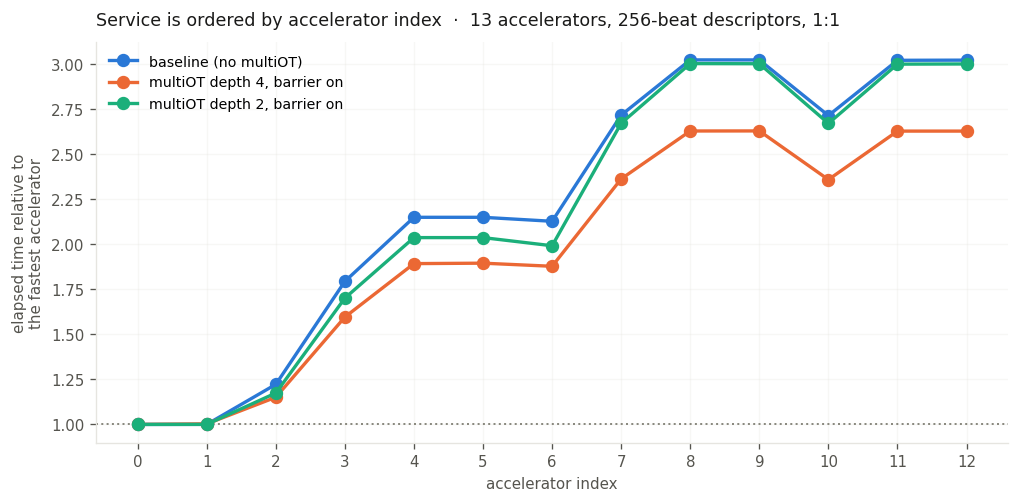

In [21]:
fig = cl.plot_fairness_by_index(arms)
plt.show()


In [22]:
for k in cl.ARM_ORDER:
    r = arms[k].runs
    s = r[(r.n_active == 13) & (r.burst == 256) & (r.rd_per_group == 1)
          & (r.wr_per_group == 1)]
    per = s.groupby("acc").cyc_active.mean()
    print(f"{cl.LABEL[k]:<30s} slowest / fastest = {per.max()/per.min():.3f}")


baseline (no multiOT)          slowest / fastest = 3.023
multiOT depth 4, barrier on    slowest / fastest = 2.629
multiOT depth 2, barrier on    slowest / fastest = 3.003


The spread between best- and worst-served accelerator is **3.02x** in the baseline at 13-way
contention, against 2.4x at 6-way in the 3x3. Depth 4 improves it to 2.63x; depth 2 does not
(3.00x).

## 5.8 Placement: index or distance?

Hop distance to the memory tile now ranges from 1 to 5, against 2 to 3 in the 3x3, so the two
candidate explanations separate better.


In [23]:
r = arms["baseline_ot1_gate0"].runs
s = r[(r.n_active == 13) & (r.burst == 256) & (r.rd_per_group == 1) & (r.wr_per_group == 1)]
t = s.groupby(["acc", "acc_y", "acc_x", "hops"]).cyc_active.mean().reset_index()
t["relative to fastest"] = (t.cyc_active / t.cyc_active.min()).round(3)
display(t)
print(f"corr(hops, elapsed)          = {t.hops.corr(t.cyc_active):+.3f}")
print(f"corr(accelerator index, elapsed) = {t.acc.corr(t.cyc_active):+.3f}")


,acc,acc_y,acc_x,hops,cyc_active,relative to fastest
0,0,0,2,2,5.406477e+05,1.000
1,1,0,3,3,5.407860e+05,1.000
2,2,1,0,1,6.609033e+05,1.222
3,3,1,1,2,9.700097e+05,1.794
4,4,1,2,3,1.162171e+06,2.150
5,5,1,3,4,1.162165e+06,2.150
6,6,2,0,2,1.150219e+06,2.127
7,7,2,1,3,1.468883e+06,2.717
8,8,2,2,4,1.634458e+06,3.023
9,9,2,3,5,1.634353e+06,3.023


corr(hops, elapsed)          = +0.748
corr(accelerator index, elapsed) = +0.942


Completion time correlates **+0.942 with accelerator index** and +0.748 with hop distance.
The accelerator at (1,0) is one hop from memory -- the closest of all thirteen -- and is the
third slowest of the fastest group, while the two at three and five hops that happen to carry
the lowest indices are the fastest. Index dominates distance.

This is consistent with the 3x3, where the same ordering appeared over a narrower hop range.
It points at arbitration order rather than transit cost. This campaign does not identify the
arbiter.


---
# 6. What this campaign establishes

1. **The rate quantum holds to 13 accelerators.** 0.9998-1.0016 64-bit words per accelerator
   clock cycle, in all three arms at all seven concurrency levels.

2. **Aggregate throughput is flat in the number of accelerators** at long descriptors:
   0.4725 to 0.4976 beats per memory-tile cycle from 1 to 13 accelerators, with the
   per-accelerator share falling as 1/n.

3. **The inbound request plane stalls heavily above 6 accelerators**, and not at or below
   that: exactly 0.0% in read-only at 1, 2, 4 and 6 accelerators, 93-98% at 10 and 13.

4. **Neither backpressure counter explains throughput.** Inbound stall varies from 93.5% to
   96.4% while throughput over the same points varies 3.4x; both counters correlate
   *positively* with throughput over all baseline points.

5. **The peak is at burst 64 for the baseline and burst 32 for both multiOT arms**, in
   balanced traffic at 13 accelerators.

6. **The highest throughput measured is 0.8819 beats per cycle** -- 1102 MB/s, 88% of the MIG
   AXI port -- at depth 4, burst 32, 13 accelerators, balanced traffic.

7. **multiOT's benefit grows with fan-in and then plateaus.** Read-only at burst 8: 1.53x at
   4 accelerators, 2.20x at 6, 2.73x at 8, 3.10x at 10 and 13.

8. **multiOT gives exactly nothing at one accelerator**, at any burst or depth, and
   **exactly nothing at burst 4096 and above**, in any mix at any concurrency.

9. **multiOT depth 4 is up to 6.0% slower than the baseline** in balanced traffic at 2
   accelerators, bursts 16-64. Repeat spread at those points is 0.04%. Read-only shows no
   such regression anywhere.

10. **Depth 4's advantage over depth 2 grows with fan-in**: 1.000 at 1-2 accelerators, 1.213
    at 6, 1.708 at 10 and 13, in read-only at burst 8.

11. **Service is less fair at higher fan-in**: 3.02x between fastest and slowest accelerator
    at 13-way contention, against 2.4x at 6-way in the 3x3.

12. **Completion time is ordered by accelerator index, not distance to memory** (+0.942
    against +0.748), over a hop range of 1 to 5.

13. **Occupancies are exact.** No counter exceeds its own denominator in any of the 1515
    memory-tile rows.


---
# 7. What this campaign does not establish

1. **Why the request plane saturates.** The counter shows the request queue is full while a
   flit is offered; it does not show whether that is because the tile is serving another
   descriptor, because the queue is short, or both.

2. **Whether the proxy ever drains two destinations at once.** No counter observes
   destination concurrency. The non-preemptive single-descriptor account remains the
   explanation that fits the data, not a measurement.

3. **The mechanism of the 2-accelerator regression.** The effect is reproducible and bounded;
   nothing here identifies its cause.

4. **What the posted-write barrier costs.** No barrier-off arm was built in either campaign,
   so every multiOT number includes it.

5. **Which physical structure sets the quantum** -- the accelerator-tile clock crossing, a
   half-rate datapath in the proxy, or the response plane's flit width. All three predict
   0.500 because the clock ratio is exactly 2.

6. **How deep the outstanding pipeline goes.** `ddr_read_multi` counts two-or-more; there is
   no three-or-more counter, so depth-4 occupancy cannot be distinguished from depth-2
   occupancy directly. The depth comparison in 5.5 is by throughput, not by occupancy.

7. **Which arbiter produces the index ordering.**

8. **Whether any NoC link is congested.** The per-router `queue_full` counters measure link
   utilization, not refusal -- they are driven from `not data_void_out`.


---
# 8. Open questions

**Q1. Which structure sets the 0.500 quantum?**
*Settles it:* re-run burst 16384 read-only at 1 and 13 accelerators with the accelerator
tiles at a clock ratio other than 2. A sink-limited crossing predicts 1.00 beats/cycle at
ratio 1 and 0.333 at ratio 3; a half-rate datapath in the proxy predicts 0.500 in all cases.

**Q2. Does the proxy ever drain two destinations at once?**
*Settles it:* a counter of memory-tile cycles with descriptors from two or more distinct
source tiles in service. Prediction: near 0% at burst >= 4096 in every arm, substantially
above 0 for depth 4 at burst 32, with aggregate tracking 0.500 x (mean distinct destinations
drained).

**Q3. Why is multiOT slower at 2 accelerators in balanced traffic?**
Bounded to bursts 16-64 and to 1:1 traffic, worst 6.0%. Read-only is unaffected, which points
at an interaction with writes -- the posted-write barrier is the obvious candidate and is
untested.
*Settles it:* the barrier-off arm, which is one bitstream.

**Q4. Why does the benefit plateau between 10 and 13 accelerators?**
Read-only burst 8 gives 3.103x at 10 and 3.099x at 13.
*Settles it:* extending the concurrency axis would require a larger mesh, or the
destination-concurrency counter of Q2 to show whether the proxy's service pattern changes
there.

**Q5. Why does arbitration favour low accelerator indices?**
*Settles it:* reading the memory-tile queue arbitration, then a placement permutation -- move
the same accelerator to a different tile index and see whether its service follows the index
or the position.

**Q6. What would accelerator-side outstanding support be worth?**
A single accelerator gains nothing from memory-tile depth because `esp_acc_dma` issues one
transaction at a time. Whether the same depth on the accelerator socket would help is
untested in either campaign.


---
# 9. Reproduction

| artifact | location |
|---|---|
| analysis code | `charlib.py` beside this notebook; `cl.load_all("4x4")` |
| data | `run_4x4_baseline/`, `run_4x4_ot4/`, `run_4x4_ot2/` -- `runs.csv`, `mem.csv`, `tile.csv` |

**Build a bitstream:**

```bash
source /opt/cad/scripts/tools_env.sh
cd <tree>/socs/xilinx-vcu118-xcvu9p
make vivado-syn 2>&1 | tee vivado_syn_<arm>.log
```

Keep `VIVADO_ENABLE_ALL_OPTIMIZATIONS` off -- it segfaults Vivado 2023.2 on this flow. All
three 4x4 arms closed timing with WNS +0.249, +0.107 and +0.217 ns and zero failing
endpoints.

**Build the software and run:**

```bash
make soft
make dma_proxy_16k_sysc_catapult-baremetal
make fpga-program
make esplink
./socgen/esp/esplink --reset
./socgen/esp/esplink --brom -i soft-build/ariane/prom.bin
./socgen/esp/esplink --dram -i soft-build/ariane/baremetal/dma_proxy_16k_sysc_catapult.bin
./socgen/esp/esplink --reset
```

`make soft` is required -- it builds `prom.bin`, without which the core resets into nothing
and the UART stays silent. `make esplink` is required after selecting a board, because
esplink compiles its target address in and is `.PHONY`.

**Capture** the UART with `socat` writing straight to a file. The run ends with
`#CSV_BYTES,<n>` as the last line; the `=== N runs ... ===` summary appears *before* the CSV
dump, not after.

**Split** on the `#BEGIN_CSV_*` markers. Strip carriage returns with `tr -d '\r'`, not
`sed 's/\r$//'` -- this capture path puts the CR at the *start* of each line.

```bash
tr -d '\r' < uart.log > clean.log
awk '/#BEGIN_CSV_RUNS/{f=1;next} /#END_CSV_RUNS/{f=0} f && NF' clean.log > runs.csv
awk '/#BEGIN_CSV_MEM/{f=1;next}  /#END_CSV_MEM/{f=0}  f && NF' clean.log > mem.csv
awk '/#BEGIN_CSV_TILE/{f=1;next} /#END_CSV_TILE/{f=0} f && NF' clean.log > tile.csv
```

Expect 3168, 505 and 8080 data rows and 24, 22 and 45 columns. `charlib` drops any row whose
column count differs from the header and reports the count, so a partial capture cannot pass
silently.
